#### <u>Определение положения при помощи меток</u>

In [16]:
# Параметры численного моделирования (Таблица 1)
chief_dims = [0.3, 0.1, 0.1]  # Размеры МКА, м
deputy_dims = [0.08, 0.08, 0.02]  # Размеры ДКА, м
closeness = 0.005  # Теснота размещения ДКА, м
deploy_velocity = 0.001  # Скорость отделения ДКА , м/с
time_total = 300  # Время моделирования, с

In [17]:
import matplotlib.pyplot as plt
import math

def bprint(s):
    print("\033[1m"+s+"\033[0m")

###### Решение уравнений ХКУ

In [18]:
import sympy

i,dr,dv,v0,r0 = sympy.var('i Δr Δv v_0 r_0')
t, ω, ε = sympy.var('t ω_0 ε', real=True)
ex,ey,ez = sympy.var('e_x e_y e_z')
e = sympy.Matrix([ex,ey,ez])

r_IC = sympy.var('r_x r_y r_z')
v_IC = sympy.var('v_x v_y v_z')
r = [sympy.Function('r_x'), sympy.Function('r_y'), sympy.Function('r_z')]
v = [sympy.Function('v_x'), sympy.Function('v_y'), sympy.Function('v_z')]

eqs = [sympy.Eq(r[0](t).diff(t), v[0](t)), 
       sympy.Eq(r[1](t).diff(t), v[1](t)), 
       sympy.Eq(r[2](t).diff(t), v[2](t)), 
       sympy.Eq(v[0](t).diff(t), -2*ω*v[1](t)), 
       sympy.Eq(v[1](t).diff(t), 3*ω**2*r[1](t) + 2*ω*v[0](t)), 
       sympy.Eq(v[2](t).diff(t), -ω**2*r[2](t))]

print(f"Уравнения:")
for j in eqs:
    display(j)
    
ics={r[0](0): r_IC[0], r[1](0): r_IC[1], r[2](0): r_IC[2], 
     v[0](0): v_IC[0], v[1](0): v_IC[1], v[2](0): v_IC[2]}

Уравнения:


Eq(Derivative(r_x(t), t), v_x(t))

Eq(Derivative(r_y(t), t), v_y(t))

Eq(Derivative(r_z(t), t), v_z(t))

Eq(Derivative(v_x(t), t), -2*ω_0*v_y(t))

Eq(Derivative(v_y(t), t), 3*ω_0**2*r_y(t) + 2*ω_0*v_x(t))

Eq(Derivative(v_z(t), t), -ω_0**2*r_z(t))

In [19]:
print(f"Решение:")
anw1 = sympy.dsolve(eqs, [r[0](t), r[1](t), r[2](t), v[0](t), v[1](t), v[2](t)], ics=ics)
for a in anw1[0:3]:
    display(a) 

Решение:


Eq(r_x(t), r_x - t*(6*r_y*ω_0 + 3*v_x) + 2*v_y*cos(t*ω_0)/ω_0 - 2*v_y/ω_0 + (6*r_y + 4*v_x/ω_0)*sin(t*ω_0))

Eq(r_y(t), 4*r_y + 2*v_x/ω_0 + v_y*sin(t*ω_0)/ω_0 - (3*r_y + 2*v_x/ω_0)*cos(t*ω_0))

Eq(r_z(t), r_z*cos(t*ω_0) + v_z*sin(t*ω_0)/ω_0)

###### Приближение $ε=tω_0\ll 1$

In [26]:
r_precise = sympy.Matrix([
    anw1[0].rhs,
    anw1[1].rhs,
    anw1[2].rhs
])
bprint("Решение ХКУ")
display(r_precise)

r_approx1 = sympy.Matrix([sympy.series(anw1[j].rhs.subs(t,ε/ω), ε, 0, 2).removeO().subs(ε,t*ω) for j in range(3)])
bprint("Решение ХКУ с точностью до o(ε)")
display(r_approx1)

r_approx2 = sympy.Matrix([sympy.series(anw1[j].rhs.subs(t,ε/ω), ε, 0, 3).removeO().subs(ε,t*ω) for j in range(3)])
bprint("Решение ХКУ с точностью до o(ε²)")
display(r_approx2)

Решение ХКУ


Matrix([
[r_x - t*(6*r_y*ω_0 + 3*v_x) + 2*v_y*cos(t*ω_0)/ω_0 - 2*v_y/ω_0 + (6*r_y + 4*v_x/ω_0)*sin(t*ω_0)],
[                        4*r_y + 2*v_x/ω_0 + v_y*sin(t*ω_0)/ω_0 - (3*r_y + 2*v_x/ω_0)*cos(t*ω_0)],
[                                                            r_z*cos(t*ω_0) + v_z*sin(t*ω_0)/ω_0]])

Решение ХКУ с точностью до o(ε)


Matrix([
[r_x + t*v_x],
[r_y + t*v_y],
[r_z + t*v_z]])

Решение ХКУ с точностью до o(ε²)


Matrix([
[                   r_x - t**2*v_y*ω_0 + t*v_x],
[r_y + t**2*ω_0**2*(3*r_y/2 + v_x/ω_0) + t*v_y],
[             -r_z*t**2*ω_0**2/2 + r_z + t*v_z]])

In [31]:
for i in range(3):
    display(anw1[i].rhs.subs(t,ε/ω))
    display(sympy.series(anw1[i].rhs.subs(t,ε/ω), ε, 0, 3))

r_x + 2*v_y*cos(ε)/ω_0 - 2*v_y/ω_0 - ε*(6*r_y*ω_0 + 3*v_x)/ω_0 + (6*r_y + 4*v_x/ω_0)*sin(ε)

-v_y*ε**2/ω_0 + v_x*ε/ω_0 + r_x + O(ε**3)

4*r_y + 2*v_x/ω_0 + v_y*sin(ε)/ω_0 - (3*r_y + 2*v_x/ω_0)*cos(ε)

ε**2*(3*r_y/2 + v_x/ω_0) + v_y*ε/ω_0 + r_y + O(ε**3)

r_z*cos(ε) + v_z*sin(ε)/ω_0

v_z*ε/ω_0 + r_z - r_z*ε**2/2 + O(ε**3)

###### Подстановка по схеме а) 
$$\vec r^0_i=(r^0+i\Delta r)\vec e_{deploy}, \hskip20px \dot{\vec r}^0_i=(v^0+i\Delta v)\vec e_{deploy}$$
$r^0$ = `chief_dims[0]/2`  <br>
$v^0$ = `deploy_velocity` <br>
$\Delta r$ = `closeness`  <br>
$\Delta v$ = `deploy_velocity/10`

In [6]:
r = r_approx1.subs([
    (r_IC[0],r0*ex+i*dr*ex), (r_IC[1],r0*ey+i*dr*ey), (r_IC[2],r0*ez+i*dr*ez),
    (v_IC[0],v0*ex+i*dv*ex), (v_IC[1],v0*ey+i*dv*ey), (v_IC[2],v0*ez+i*dv*ez)
])
r1 = r.subs(i,i-1)
r2 = r.subs(i,i)

# Подкоренное выражение формулы 4
Δ_4_sq2 = 1 - (r1.dot(r2))**2 / r1.dot(r1) / r2.dot(r2)
Δ_4_sq2 = Δ_4_sq2.simplify()
bprint("Подкоренное выражение в формуле (4) при разложении до o(ε):")
display(Δ_4_sq2)

Подкоренное выражение в формуле (4) при разложении до o(ε):


0

In [22]:
r = r_approx2.subs([
    (r_IC[0],r0*ex+i*dr*ex), (r_IC[1],r0*ey+i*dr*ey), (r_IC[2],r0*ez+i*dr*ez),
    (v_IC[0],v0*ex+i*dv*ex), (v_IC[1],v0*ey+i*dv*ey), (v_IC[2],v0*ez+i*dv*ez)
])
r1 = r.subs(i,i-1)
r2 = r.subs(i,i)
r21 = r2 - r1
r21.simplify()
display(r21)

Matrix([
[                         e_x*t*Δv + e_x*Δr - e_y*t**2*Δv*ω_0],
[e_x*t**2*Δv*ω_0 + 3*e_y*t**2*Δr*ω_0**2/2 + e_y*t*Δv + e_y*Δr],
[                     e_z*(-t**2*Δr*ω_0**2 + 2*t*Δv + 2*Δr)/2]])

In [60]:
r = r_approx2.subs([
    (r_IC[0],r0*ex+i*dr*ex), (r_IC[1],r0*ey+i*dr*ey), (r_IC[2],r0*ez+i*dr*ez),
    (v_IC[0],v0*ex+i*dv*ex), (v_IC[1],v0*ey+i*dv*ey), (v_IC[2],v0*ez+i*dv*ez)
])
r1 = r.subs(i,i-1)
r2 = r.subs(i,i)

# Видимая часть по формуле 5
Δ5_vec = r2-r1 - e.dot(r2-r1)*e
Δ5_squared = (Δ5_vec.dot(Δ5_vec)).simplify()

In [61]:
# Тест - проекция на Oyz при e=[1,0,0]
display(Δ5_vec.subs([(i,1),(ex,1),(ey,0),(ez,0)]).expand().T)
# Тест - проекция на Oxz при e=[0,1,0]
display(Δ5_vec.subs([(i,1),(ex,0),(ey,1),(ez,0)]).expand().T)

Matrix([[0, t**2*Δv*ω_0, 0]])

Matrix([[-t**2*Δv*ω_0, 0, 0]])

In [62]:
# Видимая часть [м] по формуле 4 (без поворота, считается cos(φ)=1)
Δ4_squared = (r2.dot(r2) - (r2.dot(r1))**2 / r1.dot(r1)).simplify()

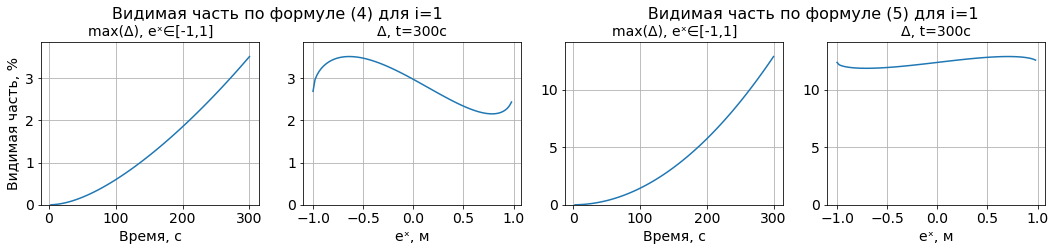

In [67]:
N = 100
t_list = [time_total/N*(i+1) for i in range(N)]
e_list = [-1 + 2*i/N for i in range(N)]

fig, axs = plt.subplots(1,4,figsize=(18,3))
for iΔ, Δ2_ in enumerate([Δ4_squared, Δ5_squared]):
    y_max, y_, t_ = [], [], 0
    Δ2_num = Δ2_.subs([
        (r0, chief_dims[0]/2), (v0, deploy_velocity), (dr, closeness), (dv, deploy_velocity/10), (ω,0.0011),  # /10 ??????????
        (ez, 0), (ey, sympy.sqrt(1-ex**2)), (i, 1)
    ]).simplify()

    for it in t_list:
        Δ2_num_t = Δ2_num.subs(t,it)
        y = [(math.sqrt(float(sympy.re(Δ2_num_t.subs(ex,ii)))) / deputy_dims[0] * 100) for ii in e_list]
        if len(y_max) == 0 or max(y) > max(y_max):
            y_ = y
            t_ = it
        y_max.append(max(y))

    
    axs[0+2*iΔ].plot(t_list, y_max)
    axs[1+2*iΔ].plot(e_list, y_)
    axs[0+2*iΔ].set_title("max(Δ), eˣ∈[-1,1]", fontsize=14)
    axs[1+2*iΔ].set_title(f"Δ, t={t_:.0f}с", fontsize=14)
    axs[0+2*iΔ].set_xlabel("Время, с", fontsize=14)
    axs[1+2*iΔ].set_xlabel("eˣ, м", fontsize=14)
    if iΔ==0:
        axs[0].set_ylabel("Видимая часть, %", fontsize=14)
    for ii in range(2):
        axs[ii+2*iΔ].grid()
        axs[ii+2*iΔ].set_ylim([0,max(y_)*1.1])
        axs[ii+2*iΔ].tick_params(axis='both', which='major', labelsize=14)
fig.suptitle(f"{' '*7}Видимая часть по формуле (4) для i=1{' '*40}Видимая часть по формуле (5) для i=1", fontsize=16, y=1.04)
plt.show()

###### Подстановка по схеме б) $$ \vec r^0 = r^0 \vec e_{deploy}, \hskip20px  \dot{\vec r}^0 = v^0 \vec e_{deploy},\hskip20px t_i=i\frac{\Delta r}{v^0}$$

In [118]:
r = r_approx2.subs([
    (r_IC[0],r0*ex), (r_IC[1],r0*ey), (r_IC[2],r0*ez),
    (v_IC[0],v0*ex), (v_IC[1],v0*ey), (v_IC[2],v0*ez), (t, t-(10-i)*dr/v0)
])
r1 = r.subs(i,i-1)
r2 = r.subs(i,i)

N_special = 10

print(f"Δt при отделении {closeness/deploy_velocity} сек")

bprint("Разница между положениями ДКА")
display((r2-r1).expand())

bprint("Разница между положениями ДКА в момент отделения")
display((r2-r1).subs(i,N_special).subs(t,dr/v0).expand())

Δt при отделении 5.0 сек
Разница между положениями ДКА


Matrix([
[                                                                                                   e_x*Δr - 2*e_y*i*Δr**2*ω_0/v_0 - 2*e_y*t*Δr*ω_0 + 21*e_y*Δr**2*ω_0/v_0],
[2*e_x*i*Δr**2*ω_0/v_0 + 2*e_x*t*Δr*ω_0 - 21*e_x*Δr**2*ω_0/v_0 + 3*e_y*i*r_0*Δr**2*ω_0**2/v_0**2 + 3*e_y*r_0*t*Δr*ω_0**2/v_0 - 63*e_y*r_0*Δr**2*ω_0**2/(2*v_0**2) + e_y*Δr],
[                                                                   -e_z*i*r_0*Δr**2*ω_0**2/v_0**2 - e_z*r_0*t*Δr*ω_0**2/v_0 + 21*e_z*r_0*Δr**2*ω_0**2/(2*v_0**2) + e_z*Δr]])

Разница между положениями ДКА в момент отделения


Matrix([
[                                    e_x*Δr - e_y*Δr**2*ω_0/v_0],
[e_x*Δr**2*ω_0/v_0 + 3*e_y*r_0*Δr**2*ω_0**2/(2*v_0**2) + e_y*Δr],
[                     -e_z*r_0*Δr**2*ω_0**2/(2*v_0**2) + e_z*Δr]])

In [119]:
# Видимая часть по формуле 5
Δ5_vec = r2-r1 - e.dot(r2-r1)*e
Δ5_squared = (Δ5_vec.dot(Δ5_vec)).simplify()

In [120]:
# Тест - проекция на Oyz при e=[1,0,0]
display(Δ5_vec.subs([(i,N_special),(ex,1),(ey,0),(ez,0)]).expand().T)
# Тест - проекция на Oxz при e=[0,1,0]
display(Δ5_vec.subs([(i,N_special),(ex,0),(ey,1),(ez,0)]).expand().T)

Matrix([[0, 2*t*Δr*ω_0 - Δr**2*ω_0/v_0, 0]])

Matrix([[-2*t*Δr*ω_0 + Δr**2*ω_0/v_0, 0, 0]])

In [108]:
# Видимая часть [м] по формуле 4 (без поворота, считается cos(φ)=1)
Δ4_squared = (r2.dot(r2) - (r2.dot(r1))**2 / r1.dot(r1)).simplify()
# Δ4_squared = (1 - (r2.dot(r1))**2 / r1.dot(r1) / r2.dot(r2)).simplify()

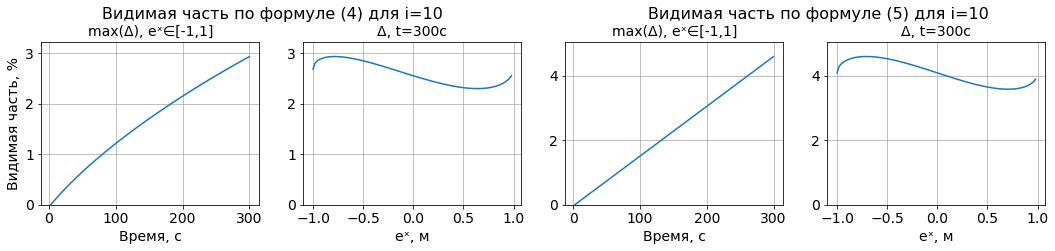

In [123]:
N = 100
t_list = [time_total/N*(i+1) for i in range(N)]
e_list = [-1 + 2*i/N for i in range(N)]

fig, axs = plt.subplots(1,4,figsize=(18,3))
for iΔ, Δ2_ in enumerate([Δ4_squared, Δ5_squared]):
    y_max, y_, t_ = [], [], 0
    Δ2_num = Δ2_.subs([
        (r0, chief_dims[0]/2), (v0, deploy_velocity), (dr, closeness), (dv, deploy_velocity/10), (ω,0.0011),  # /10 ??????????
        (ez, 0), (ey, -sympy.sqrt(1-ex**2)), (i, N_special)
    ]).simplify()

    for it in t_list:
        Δ2_num_t = Δ2_num.subs(t,it)
        y = [(math.sqrt(float(sympy.re(Δ2_num_t.subs(ex,ii)))) / deputy_dims[0] * 100) for ii in e_list]
        if len(y_max) == 0 or max(y) > max(y_max):
            y_ = y
            t_ = it
        y_max.append(max(y))

    
    axs[0+2*iΔ].plot(t_list, y_max)
    axs[1+2*iΔ].plot(e_list, y_)
    axs[0+2*iΔ].set_title("max(Δ), eˣ∈[-1,1]", fontsize=14)
    axs[1+2*iΔ].set_title(f"Δ, t={t_:.0f}с", fontsize=14)
    axs[0+2*iΔ].set_xlabel("Время, с", fontsize=14)
    axs[1+2*iΔ].set_xlabel("eˣ, м", fontsize=14)
    if iΔ==0:
        axs[0].set_ylabel("Видимая часть, %", fontsize=14)
    for ii in range(2):
        axs[ii+2*iΔ].grid()
        axs[ii+2*iΔ].set_ylim([0,max(y_)*1.1])
        axs[ii+2*iΔ].tick_params(axis='both', which='major', labelsize=14)
fig.suptitle(f"{' '*7}Видимая часть по формуле (4) для i={N_special}{' '*40}Видимая часть по формуле (5) для i={N_special}", fontsize=16, y=1.04)
plt.show()

###### Подстановка по схеме в) $$ \vec r^0 = (1+id r / r^0) \vec r_{deploy}, \hskip20px  \dot{\vec r}^0 = v^0 \vec e_{deploy},\hskip20px \vec r_{deploy}\perp \vec e_{deploy} \hskip20px |\vec r_{deploy}|=r^0$$

In [122]:
i,dr,dv,v0,r0 = sympy.var('i dr dv v0 r0')
ex,ey,ez,rdx,rdy,rdz = sympy.var('e_x e_y e_z r^{deploy}_x r^{deploy}_y r^{deploy}_z')

# Тут типа r_deploy единичный
r_approxed = r_approxed.subs([
    (r_0[0],r0*rdx+i*dr*rdx), (r_0[1],r0*rdy+i*dr*rdy), (r_0[2],r0*rdz+i*dr*rdz),
    (v_0[0],v0*ex), (v_0[1],v0*ey), (v_0[2],v0*ez)])
r_approxed.expand().simplify()
r_approxed

Matrix([
[                                                       dr*i*r^{deploy}_x + e_x*t*v0 - e_y*t**2*v0*ω_0 + r0*r^{deploy}_x],
[dr*i*r^{deploy}_y + e_y*t*v0 + r0*r^{deploy}_y + t**2*ω_0**2*(3*dr*i*r^{deploy}_y/2 + e_x*v0/ω_0 + 3*r0*r^{deploy}_y/2)],
[                   dr*i*r^{deploy}_z + e_z*t*v0 + r0*r^{deploy}_z - t**2*ω_0**2*(dr*i*r^{deploy}_z + r0*r^{deploy}_z)/2]])

In [112]:
# r_approxed = r_approxed.subs(ez, 0).subs(rdx, 0).subs(rdy, 0)

In [124]:
r1 = r_approxed.subs(i,i-1)
r2 = r_approxed.subs(i,i)
r_12 = r2 - r1
r_12 = r_12.expand()
r_12.simplify()
# r_12 = r_12.expand()
r_12

Matrix([
[                      dr*r^{deploy}_x],
[dr*r^{deploy}_y*(3*t**2*ω_0**2 + 2)/2],
[ dr*r^{deploy}_z*(-t**2*ω_0**2 + 2)/2]])

In [114]:
Δ_4_sq2 = 1 - (r1.dot(r2))**2 / r1.dot(r1) / r2.dot(r2)
#Δ_4_sq2 = Δ_4_sq2.simplify()
#Δ_4_sq2

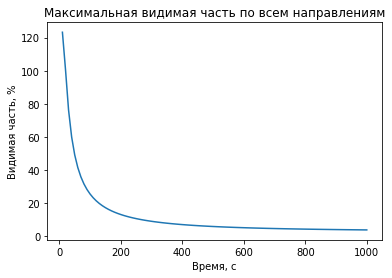

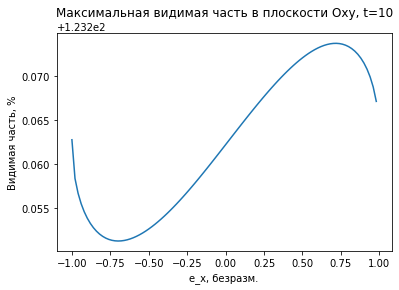

In [117]:
import matplotlib.pyplot as plt
import math

y_max, y_, t_ = [], [], 0
t_list = [10*(i+1) for i in range(100)]
e_list = [-1 + 2*i/100 for i in range(100)]

Pr1_n = Δ_4_sq2.subs([(dr, 0.005), (r0, 0.1), (v0, 0.01), (ω,0.0011),
                      (rdz, 0), (rdx, ey), (rdy, -ex)])
Pr1_n = Pr1_n.subs([(ez, 0), (ex, sympy.sqrt(1-ey**2))]).simplify()

for it in t_list:
    tmp = Pr1_n.subs(t,it)
    y = [math.sqrt(float(sympy.re(tmp.subs(ey,i)))) / 0.02 * 100 for i in e_list]
    if len(y_max) == 0 or max(y) > max(y_max):
        y_ = y
        t_ = it
    y_max.append(max(y))
    
plt.plot(t_list, y_max)
plt.title("Максимальная видимая часть по всем направлениям")
plt.xlabel("Время, с")
plt.ylabel("Видимая часть, %")
plt.show()

plt.plot(e_list, y_)
plt.title(f"Максимальная видимая часть в плоскости Oxy, t={t_}")
plt.xlabel("e_x, безразм.")
plt.ylabel("Видимая часть, %")
plt.show()

In [76]:
e = sympy.Matrix([ex,ey,ez])
Pr_vec = r2 - r1 - e.dot(r2-r1)*e
Pr2 = (Pr_vec.dot(Pr_vec)).simplify()

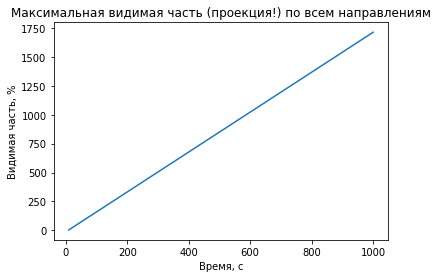

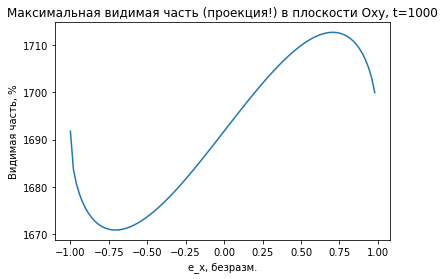

In [79]:
import matplotlib.pyplot as plt
import math

y_max, y_, t_ = [], [], 0
t_list = [10*(i+1) for i in range(100)]
e_list = [-1 + 2*i/100 for i in range(100)]
Pr1_n = Pr2.subs([(dr, 0.005), (r0, 0.15), (v0, 0.01), (ω,0.0011)])
Pr1_n = Pr1_n.subs([(ez, 0), (ex, sympy.sqrt(1-ey**2))]).simplify()

for it in t_list:
    tmp = Pr1_n.subs(t,it)
    y = [math.sqrt(float(sympy.re(tmp.subs(ey,i)))) / 0.02 * 100 for i in e_list]
    if len(y_max) == 0 or max(y) > max(y_max):
        y_ = y
        t_ = it
    y_max.append(max(y))
    
plt.plot(t_list, y_max)
plt.title("Максимальная видимая часть (проекция!) по всем направлениям")
plt.xlabel("Время, с")
plt.ylabel("Видимая часть, %")
plt.show()

plt.plot(e_list, y_)
plt.title(f"Максимальная видимая часть (проекция!) в плоскости Oxy, t={t_}")
plt.xlabel("e_x, безразм.")
plt.ylabel("Видимая часть, %")
plt.show()

Максимальная видимая часть Δ=37.6% | t=50c
Максимальная видимая часть Δ=31.6% | t=100c
Максимальная видимая часть Δ=28.6% | t=150c


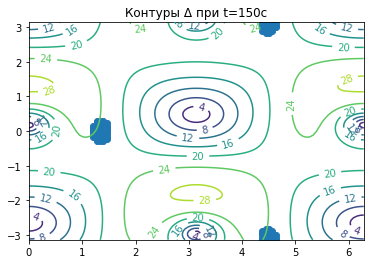

In [66]:
import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
from math import sin, cos, sqrt, pi

ω = 0.0011

def LOS(t, rx, ry, rz, vx, vy, vz, camx, camy, camz):
    x = rx - 2*vy/ω - (6*ry*ω + 3*vx)*t + 2*vy/ω*cos(ω*t) + (6*ry + 4*vx/ω)*sin(ω*t)
    y = 4*ry + 2*vx/ω + vy/ω*sin(ω*t) - (3*ry + 2*vx/ω)*cos(ω*t)
    z = rz*cos(ω*t) + vz/ω*sin(ω*t)
    return x-camx, y-camy, z-camz

def Δ(t, i, φ, θ, dr, dv, v0, rx, ry, rz, camx, camy, camz):
    ex = cos(θ)*cos(φ)
    ey = cos(θ)*sin(φ)
    ez = sin(θ)
    j = i-1
    LOS1 = LOS(t=t, camx=camx, camy=camy, camz=camz,
               rx=rx+j*dr*ex,
               ry=ry+j*dr*ey,
               rz=rz+j*dr*ez,
               vx=v0*ex+j*dv*ex,
               vy=v0*ey+j*dv*ey,
               vz=v0*ez+j*dv*ez)
    j = i
    LOS2 = LOS(t=t, camx=camx, camy=camy, camz=camz,
               rx=rx+j*dr*ex,
               ry=ry+j*dr*ey,
               rz=rz+j*dr*ez,
               vx=v0*ex+j*dv*ex,
               vy=v0*ey+j*dv*ey,
               vz=v0*ez+j*dv*ez)
    cos_a2 = (LOS1[0]*LOS2[0] + LOS1[1]*LOS2[1] + LOS1[2]*LOS2[2])**2 / \
             (LOS1[0]**2 + LOS1[1]**2 + LOS1[2]**2) / \
             (LOS2[0]**2 + LOS2[1]**2 + LOS2[2]**2)
    return sqrt(LOS2[0]**2 + LOS2[1]**2 + LOS2[2]**2) * sqrt(1 - cos_a2)

def Δ_distribution():
    Δs = [[0 for _ in range(N)] for _ in range(N)]
    for iφ, φ in enumerate(φ_list):
        for iθ, θ in enumerate(θ_list):
            ex = cos(θ)*cos(φ)
            ey = cos(θ)*sin(φ)
            ez = sin(θ)
            rx = 0.15 * ex
            ry = 0.15 * ey
            rz = 0.15 * ez
            Δs[iφ][iθ] = Δ(t, i, φ, θ, dr, dv, v0, rx, ry, rz, camx, camy, camz) / markerSize * 100
    return Δs

N = 100
φ_list = [0+2*pi*j/(N-1) for j in range(N)]
θ_list = [-pi+2*pi*j/(N-1) for j in range(N)]

for t in [50,100,150]:
    # camx, camy, camz = 0,0,0
    camx, camy, camz = 0.14,0.05,0
    i = 1
    v0 = 0.001;
    dv = 0.000;
    dr = 0.01;
    markerSize = 0.02

    
    Δs = np.array(Δ_distribution())
    max_index = np.where(Δs>(np.max(Δs)*0.99))

    Δs_flat = [item for sublist in Δs for item in sublist]
    print(f"Максимальная видимая часть Δ={np.max(Δs):.1f}% | t={t}c")

φ_list = np.array(φ_list)
θ_list = np.array(θ_list)
CS = plt.contour(φ_list, θ_list, Δs)
plt.clabel(CS, fontsize=10)
plt.title(f'Контуры Δ при t={t}c')
plt.scatter(φ_list[max_index[0]], θ_list[max_index[1]])
plt.show()